In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
df = pd.read_csv("data.csv")
print(df.columns)

Index(['user_id', 'movie_id', 'movie_name', 'genre', 'timestamp',
       'watched_duration_pct', 'liked', 'disliked', 'watch_later', 'shared',
       're_watched', 'watched_full', 'device_type', 'transaction_type',
       'amount_paid', 'country', 'language', 'user_rating', 'age_group',
       'safety_flag', 'data_source', 'mood', 'search_query', 'search_keywords',
       'session_id', 'tags'],
      dtype='object')


In [4]:
columns = ['watched_duration_pct', 'liked', 'language', 'amount_paid']

df = df.dropna()
print(len(df))


265


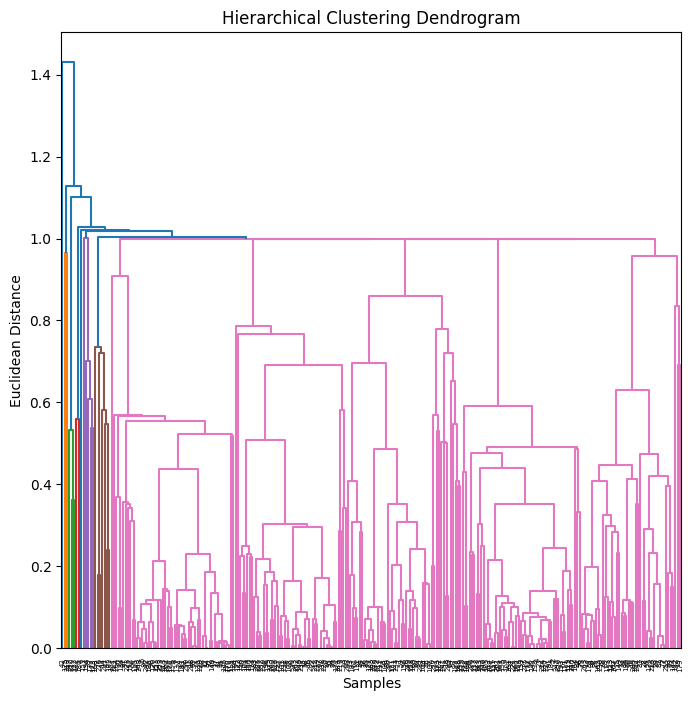

In [22]:
cat_col = ['liked', 'language']
num_col = ['watched_duration_pct', 'amount_paid']

preprocessor = ColumnTransformer(
    transformers  = [
        ('cat', OneHotEncoder(drop = 'first'), cat_col),
        ('num', StandardScaler(), num_col)
    ]
)
X = df[columns]
X_processed = preprocessor.fit_transform(X)

X = np.array(X_processed)

plt.figure(figsize = (8,8))
Z = linkage(X, method = 'single')
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [20]:
ag = AgglomerativeClustering(n_clusters = 3, linkage = 'ward')
clusters = ag.fit_predict(X)

pca = PCA(n_components = 2)
X = pca.fit_transform(X)


C:\Users\abhay\AppData\Local\Temp\ipykernel_20668\72577612.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y["Clusters"] = clusters


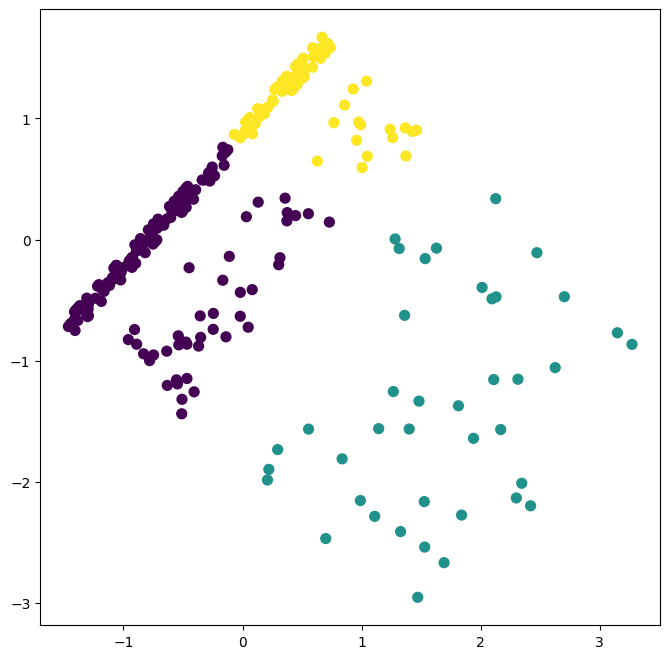

In [21]:
Y = df[columns]
Y["Clusters"] = clusters

plt.figure(figsize = (8,8))
plt.scatter(X[:, 0], X[:, 1], c = clusters, s = 50)
plt.show()